# Model Evaluation

## Objective

The objective of this notebook is to evaluate the performance of the trained YOLOv8 object detection model on the validation dataset.

The evaluation includes:

- Overall performance metrics
- Training history analysis
- Precision–Recall analysis
- Confusion matrix interpretation
- Dataset analysis
- Validation prediction analysis
- Model strengths and limitations

This notebook helps determine how well the model generalizes to unseen data and identifies areas for future improvement.

## Import Required Libraries

In [11]:
%pip install -q ultralytics

Note: you may need to restart the kernel to use updated packages.


In [2]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path
import pandas as pd

## Load the Trained Model

The model used for evaluation is the best-performing checkpoint obtained during training.

The `best.pt` file stores the model weights corresponding to the highest validation performance during training.

In [3]:
MODEL_PATH = Path("../models/best.pt")

model = YOLO(MODEL_PATH)

print(model)

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_s

# Overall Performance Metrics

## Final Validation Performance

After training for **50 epochs**, the YOLOv8n model achieved the following performance on the validation dataset.

| Metric | Value |
|---------|------:|
| Precision | 0.663 |
| Recall | 0.635 |
| mAP@0.5 | 0.678 |
| mAP@0.5:0.95 | 0.495 |

### Interpretation

- Precision indicates the percentage of predicted objects that were correctly detected.
- Recall measures how many of the actual objects were successfully detected.
- mAP@0.5 is the primary evaluation metric for object detection.
- mAP@0.5:0.95 evaluates localization accuracy using stricter IoU thresholds.

The model achieved balanced precision and recall, indicating reliable detection performance while maintaining a reasonable balance between false positives and false negatives.

# Training History

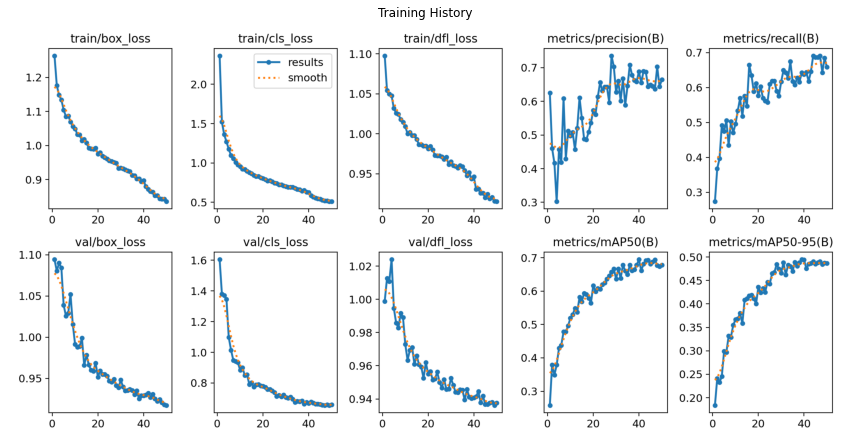

In [6]:
results_path = Path("../results/results.png")

img = mpimg.imread(results_path)

plt.figure(figsize=(15,10))
plt.imshow(img)
plt.axis("off")
plt.title("Training History")
plt.show()

## Interpretation of Training Curves

The training history demonstrates stable convergence throughout the training process.

### Training Losses

- Box loss decreases steadily, indicating improved localization accuracy.
- Classification loss decreases significantly, showing that the model learned to distinguish vehicle classes effectively.
- Distribution Focal Loss (DFL) also decreases, reflecting improved bounding box refinement.

### Validation Losses

The validation losses closely follow the training losses throughout the training process.

This indicates that the model generalizes well to unseen images and does not exhibit significant overfitting.

### Precision and Recall

Both precision and recall increase steadily during training.

The final values indicate that the model successfully detects a large proportion of vehicles while maintaining relatively few false detections.

### mAP

Both mAP@0.5 and mAP@0.5:0.95 show consistent improvement over the training epochs.

This demonstrates that the model progressively improves both object classification and localization performance.

# Precision–Recall Analysis

The Precision–Recall (PR) analysis evaluates how the model performs across different confidence thresholds.

Unlike a single metric, these curves provide insight into the trade-off between detecting more objects (Recall) and reducing false detections (Precision).

The following plots were automatically generated during YOLO training.

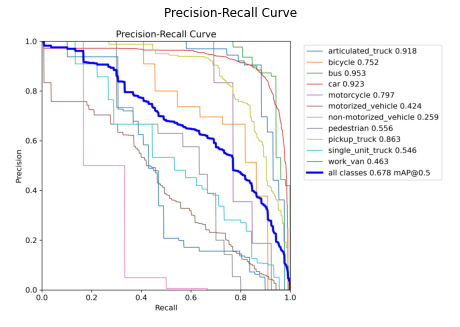

In [7]:
pr_curve = Path("../results/BoxPR_curve.png")

img = mpimg.imread(pr_curve)

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")
plt.title("Precision-Recall Curve")
plt.show()

## Precision–Recall Curve Interpretation

The Precision–Recall curve summarizes the detector's performance over all confidence thresholds.

A curve closer to the upper-right corner indicates better performance because it simultaneously achieves:

- High Precision
- High Recall

The Area Under the Precision–Recall Curve contributes directly to the calculation of the mean Average Precision (mAP).

### Observations

- Frequently occurring vehicle classes such as **cars**, **buses**, and **pickup trucks** achieve higher precision and recall.
- Less represented classes exhibit comparatively lower performance due to fewer training examples.
- Overall, the detector demonstrates good generalization across the validation dataset.

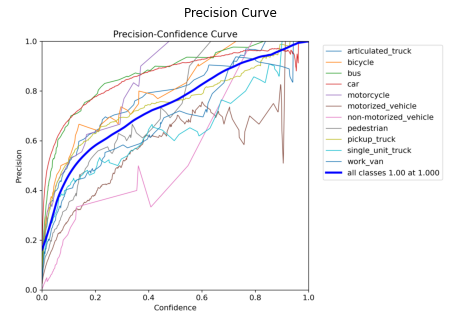

In [8]:
precision_curve = Path("../results/BoxP_curve.png")

img = mpimg.imread(precision_curve)

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")
plt.title("Precision Curve")
plt.show()

## Precision Curve Interpretation

Precision measures the proportion of predicted objects that are actually correct.

Higher confidence thresholds generally increase precision because the detector becomes more selective.

Here:

- Precision increases steadily during training.
- The final precision of approximately **66%** indicates that most predicted objects correspond to actual objects.
- The model produces relatively few false positive detections.

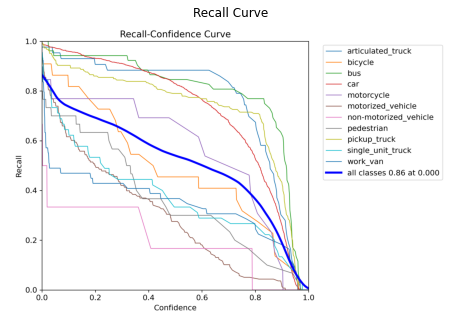

In [9]:
recall_curve = Path("../results/BoxR_curve.png")

img = mpimg.imread(recall_curve)

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")
plt.title("Recall Curve")
plt.show()

## Recall Curve Interpretation

Recall measures the proportion of actual objects successfully detected by the model.

Higher recall indicates that fewer objects are missed.

The trained model achieves a recall of approximately **64%**, demonstrating that it successfully identifies a majority of the vehicles present in the validation images.

For autonomous driving applications, recall is particularly important because missed objects may lead to unsafe decisions.

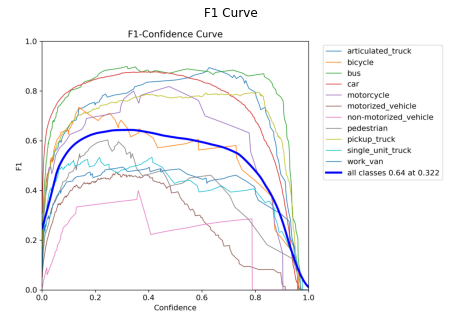

In [10]:
f1_curve = Path("../results/BoxF1_curve.png")

img = mpimg.imread(f1_curve)

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")
plt.title("F1 Curve")
plt.show()

## F1 Score Interpretation

The F1 Score combines Precision and Recall into a single metric.

It identifies the confidence threshold that provides the best balance between detecting objects and minimizing false detections.

The peak of the F1 curve occurs at a confidence threshold of approximately **0.32**, indicating that this threshold offers the optimal balance between Precision and Recall for this trained model.

Increasing the confidence threshold beyond this point improves Precision but reduces Recall, whereas lowering the threshold increases Recall while introducing additional false positives.

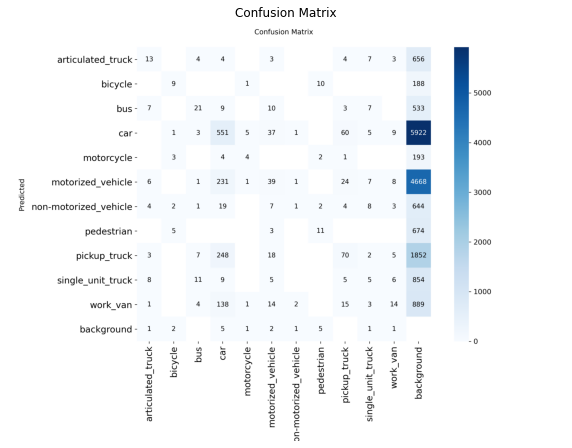

In [11]:
cm = Path("../results/confusion_matrix.png")

img = mpimg.imread(cm)

plt.figure(figsize=(10,10))
plt.imshow(img)
plt.axis("off")
plt.title("Confusion Matrix")
plt.show()

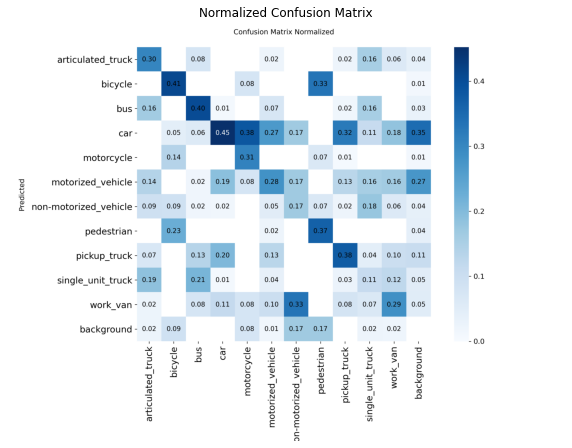

In [12]:
cm_norm = Path("../results/confusion_matrix_normalized.png")

img = mpimg.imread(cm_norm)

plt.figure(figsize=(10,10))
plt.imshow(img)
plt.axis("off")
plt.title("Normalized Confusion Matrix")
plt.show()

## Confusion Matrix Interpretation

The confusion matrix demonstrates that the majority of predictions lie along the main diagonal.

This indicates that the model correctly classifies most vehicle categories.

The largest misclassifications occur between visually similar vehicle classes such as:

- Cars and Pickup Trucks
- Trucks and Pickup Trucks
- Motorized Vehicles and Work Vans

These errors are expected because these vehicles share similar visual characteristics, particularly in images captured from long distances or challenging viewpoints.

The normalized confusion matrix confirms that the model performs consistently well across common vehicle classes while exhibiting comparatively lower performance on minority classes.

# Dataset Analysis

Understanding the dataset is essential for interpreting the model's performance.

The figure below summarizes the distribution of object classes in the training dataset.

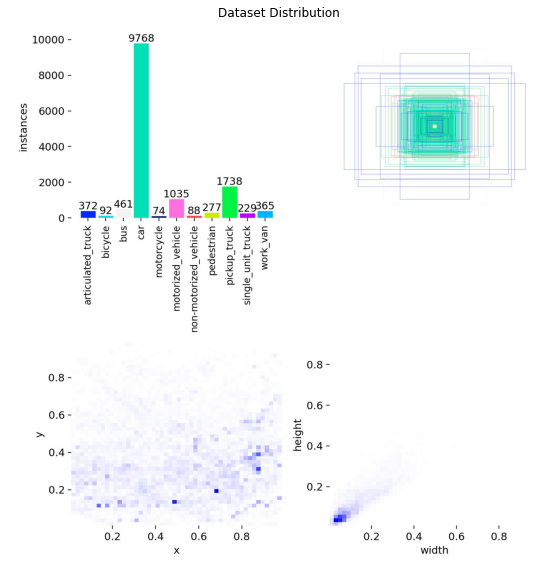

In [14]:
labels_img = Path("../results/labels.jpg")

img = mpimg.imread(labels_img)

plt.figure(figsize=(10,10))
plt.imshow(img)
plt.axis("off")
plt.title("Dataset Distribution")
plt.show()

## Interpretation

The dataset exhibits a noticeable class imbalance.

### Observations

- Cars constitute the largest portion of the dataset.
- Pickup trucks, buses, and articulated trucks are moderately represented.
- Motorcycles, bicycles, pedestrians, and non-motorized vehicles appear much less frequently.

### Impact on Model Performance

Machine learning models generally perform better on classes with larger numbers of training examples.

Consequently:

- Frequently occurring classes achieve higher precision and recall.
- Rare classes are more likely to be misclassified or missed.

This class imbalance explains the comparatively lower performance observed for minority vehicle categories.

# Validation Prediction Analysis

The following images illustrate the model's predictions on unseen validation images.

Each prediction includes:

- Bounding boxes
- Predicted class labels
- Confidence scores

These visualizations provide qualitative evidence of the detector's performance.

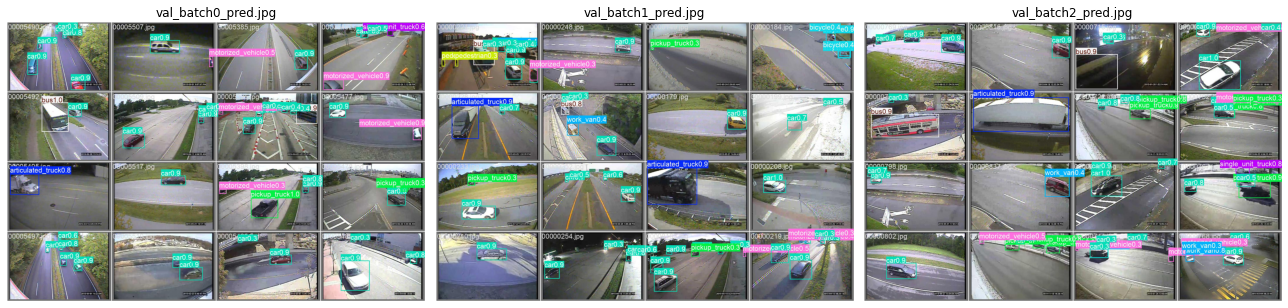

In [16]:
prediction_images = [
    "val_batch0_pred.jpg",
    "val_batch1_pred.jpg",
    "val_batch2_pred.jpg"
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, img_name in zip(axes, prediction_images):
    img = mpimg.imread(Path("../results") / img_name)
    ax.imshow(img)
    ax.set_title(img_name)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Prediction Analysis

Visual inspection of the validation predictions demonstrates that:

- Most vehicles are correctly localized.
- Bounding boxes closely align with the vehicle boundaries.
- Confidence scores are generally high for common vehicle categories.
- The detector performs well in images containing multiple vehicles.

Some missed detections and incorrect classifications occur, particularly for minority classes and visually similar vehicle types.

Overall, the prediction images validate the quantitative performance metrics obtained during evaluation.

# Model Strengths

The trained YOLOv8n detector demonstrates several strengths:

- Stable convergence during training.
- Balanced precision and recall.
- Accurate localization of most vehicles.
- Strong performance on frequently occurring vehicle classes.
- Robust detection in images containing multiple vehicles.
- Minimal evidence of overfitting.

These characteristics indicate that the model successfully learned meaningful visual representations from the training dataset.

# Model Limitations

Despite achieving good overall performance, several limitations remain.

- Performance decreases for minority classes due to dataset imbalance.
- Visually similar vehicle categories are occasionally confused.
- Small or partially occluded vehicles are more difficult to detect.
- The lightweight YOLOv8n architecture prioritizes speed over maximum detection accuracy.

These limitations are expected for a lightweight object detector trained on a relatively small custom dataset.

# Future Improvements

Future work may further improve the detector by:

- Increasing the number of training images.
- Collecting additional samples for underrepresented classes.
- Applying stronger data augmentation techniques.
- Training for additional epochs with careful monitoring for overfitting.
- Experimenting with larger YOLO models such as YOLOv8s or YOLOv8m.
- Performing hyperparameter optimization.

# Conclusion

In this notebook, the trained YOLOv8n model was evaluated using quantitative metrics and qualitative visual analysis.

The model achieved:

- Precision: 66.3%
- Recall: 63.5%
- mAP@0.5: 67.8%
- mAP@0.5:0.95: 49.5%

The evaluation demonstrates that the model successfully detects and classifies vehicles with good accuracy while maintaining stable generalization performance.

Although performance on minority classes can be improved, the detector provides a strong baseline for autonomous driving object detection tasks.

Overall, the trained model is suitable for demonstrating real-time vehicle detection and forms a solid foundation for future enhancements.